In [1]:
import numpy as np 
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df= pd.read_csv("marketing_AB.csv")

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.duplicated(subset = 'user id').sum()

0

In [7]:
df.drop(['Unnamed: 0' , 'user id'   ], axis =1 , inplace =True )

In [8]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 18.5+ MB


In [14]:
df_cat = df[['test group',  'converted', 'most ads day',  'most ads hour'  ]]

df_cat.nunique()

test group        2
converted         2
most ads day      7
most ads hour    24
dtype: int64

In [16]:
for i in df_cat.columns :
    print(i.upper(),  ":", df_cat[i].unique())   

TEST GROUP : ['ad' 'psa']
CONVERTED : [False  True]
MOST ADS DAY : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
MOST ADS HOUR : [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


Univariate analysis

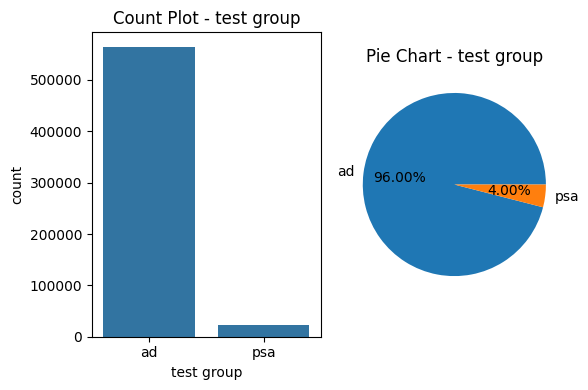

In [18]:
variable = 'test group'

plt.figure(figsize=(6, 4))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count Plot - {variable}') 

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()
plt.show() 

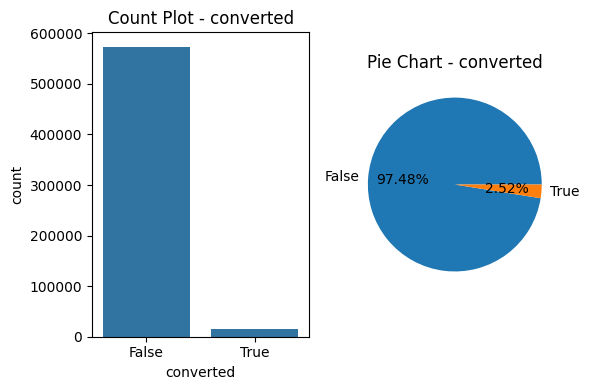

In [20]:
variable  = 'converted'


plt.figure(figsize=(6, 4))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count Plot - {variable}') 

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()
plt.show() 



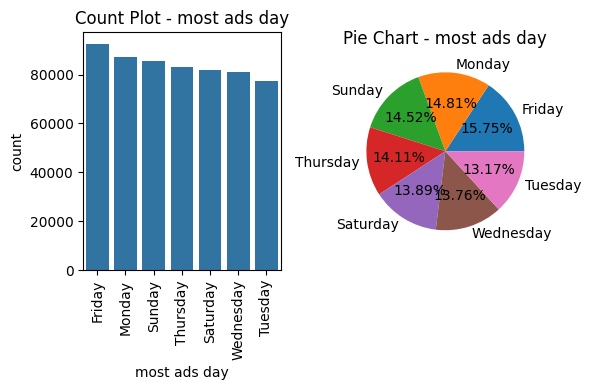

In [24]:
    variable  = 'most ads day'


plt.figure(figsize=(6, 4))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat, order = df_cat['most ads day'].value_counts().index)
plt.title(f'Count Plot - {variable}') 
plt.xticks(rotation =90)

# Pie chart
plt.subplot(1, 2, 2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

# Adjust layout
plt.tight_layout()
plt.show() 


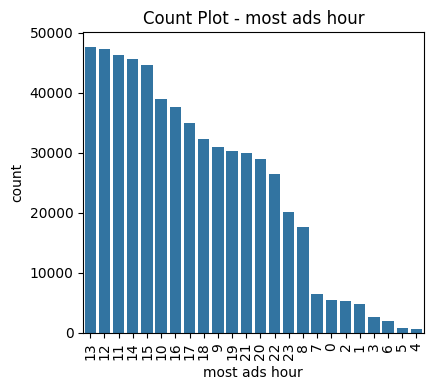

In [26]:
    variable  = 'most ads hour'


plt.figure(figsize=(8, 4))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(x=variable, data=df_cat, order = df_cat['most ads hour'].value_counts().index)
plt.title(f'Count Plot - {variable}') 
plt.xticks(rotation =90)



# Adjust layout
plt.tight_layout()
plt.show() 


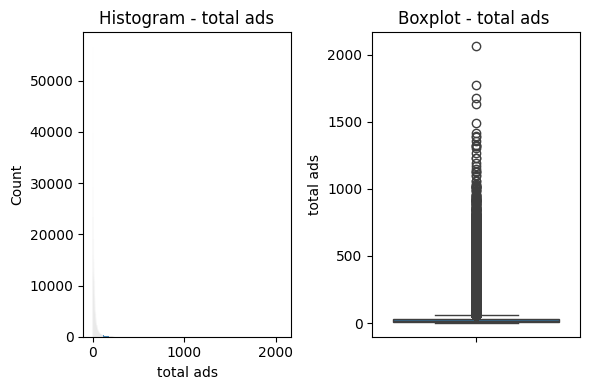

In [29]:
variable  = 'total ads'


plt.figure(figsize=(6, 4))

# his plot
plt.subplot(1, 2, 1)
sns.histplot(x=variable,data =df)
plt.title(f'Histogram - {variable}') 


# Pie chart
plt.subplot(1, 2, 2)
sns.boxplot(y= variable, data = df)
plt.title(f'Boxplot - {variable} ')

# Adjust layout
plt.tight_layout()
plt.show() 


In [30]:
df['total ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

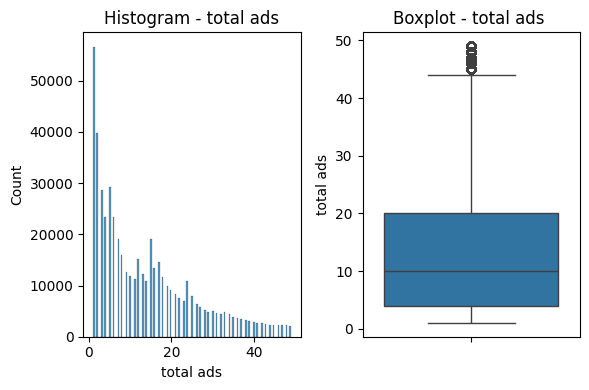

In [31]:
variable  = 'total ads'


plt.figure(figsize=(6, 4))

# his plot
plt.subplot(1, 2, 1)
sns.histplot(x=variable,data =df[df['total ads']<50])
plt.title(f'Histogram - {variable}') 


# Pie chart
plt.subplot(1, 2, 2)
sns.boxplot(y= variable, data = df[df['total ads']<50])
plt.title(f'Boxplot - {variable} ')

# Adjust layout
plt.tight_layout()
plt.show() 


bivariate analysis

In [33]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [35]:
ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'] , normalize= 'index' )
ct_conversion_test_group


converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


<Axes: xlabel='test group'>

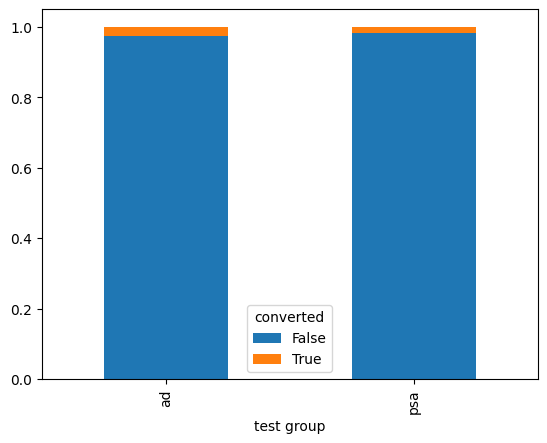

In [36]:
ct_conversion_test_group.plot.bar(stacked = True)

converted        False     True 
most ads day                    
Monday        0.967188  0.032812
Tuesday       0.970160  0.029840
Wednesday     0.975058  0.024942
Sunday        0.975524  0.024476
Friday        0.977788  0.022212
Thursday      0.978429  0.021571
Saturday      0.978949  0.021051


<Axes: xlabel='most ads day'>

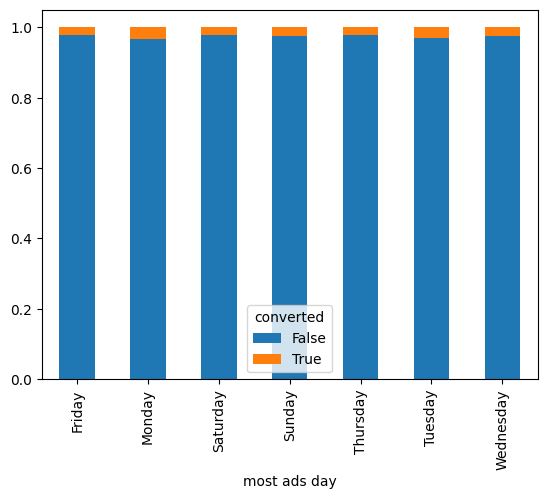

In [47]:
ct_conversion_day = pd.crosstab(df['most ads day'], df['converted'] , normalize= 'index' )
print(ct_conversion_day.sort_values(by = True , ascending = False))
ct_conversion_day.plot.bar(stacked = True)


converted         False     True 
most ads hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


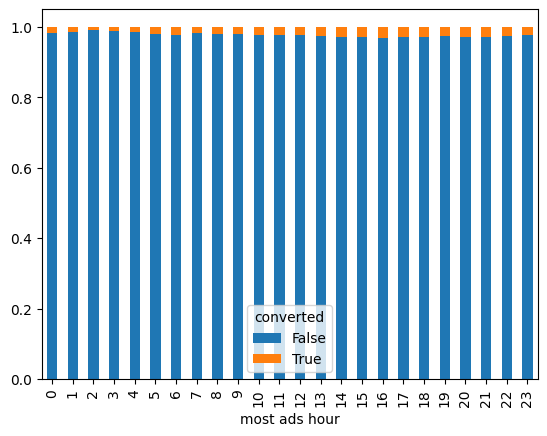

In [40]:
ct_conversion_hour = pd.crosstab(df['most ads hour'],df['converted'], normalize = 'index')
print(ct_conversion_hour.sort_values(by= True , ascending  = False))
ct_conversion_hour.plot.bar(stacked= True);

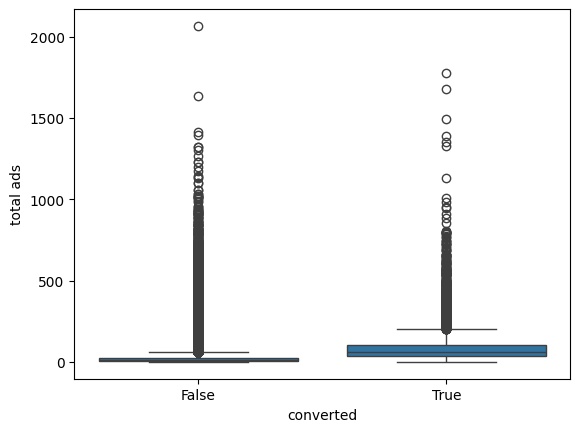

In [43]:
sns.boxplot(x =  'converted', y= 'total ads', data = df );

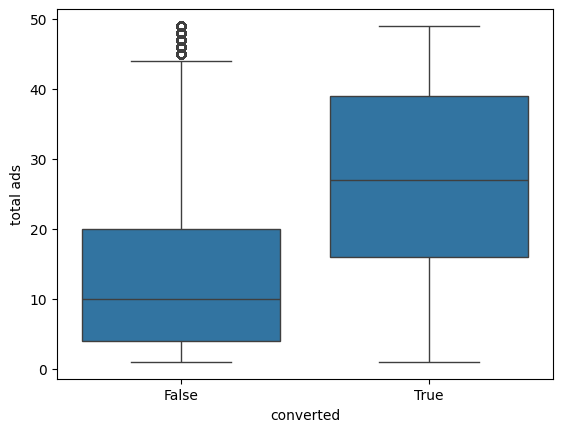

In [44]:
sns.boxplot(x =  'converted', y= 'total ads', data = df[df['total ads']<50] );

statistical tests

In [52]:
from scipy.stats import chi2_contingency
alpha = 0.05
for variable in df_cat.columns:
    if variable != 'converted' :
        contingency_table  = pd.crosstab(df_cat[variable], df_cat['converted'])



        chi2,p,_,_ = chi2_contingency( contingency_table)


        print(f"\nchi-square test for {variable} vs converted :")
        print(f"Chi-square value: {chi2}")
        print(f"p-value:{p} ")


        if p < alpha:
            print(f"the difference in conversion rates acorss {variable}   is statistically significant ")
            print (f"there is no significant difference  in conversion rates across {variable} ")


            #less than 0.05


chi-square test for test group vs converted :
Chi-square value: 54.005823883685245
p-value:1.9989623063390075e-13 
the difference in conversion rates acorss test group   is statistically significant 
there is no significant difference  in conversion rates across test group 

chi-square test for most ads day vs converted :
Chi-square value: 410.0478857936585
p-value:1.932184379244731e-85 
the difference in conversion rates acorss most ads day   is statistically significant 
there is no significant difference  in conversion rates across most ads day 

chi-square test for most ads hour vs converted :
Chi-square value: 430.76869230822086
p-value:8.027629823696771e-77 
the difference in conversion rates acorss most ads hour   is statistically significant 
there is no significant difference  in conversion rates across most ads hour 


In [53]:
df_cat.columns

Index(['test group', 'converted', 'most ads day', 'most ads hour'], dtype='object')